## Executive Summary & Business Recommendations

### Executive Summary
1. **Objective:** Built and evaluated machine learning classification models to automate credit risk assessment and predict loan approval status (`Loan_Status`) based on applicant financial and demographic features.
2. **Top Model Performance:** The **Random Forest Classifier** achieved the highest overall accuracy (**82.50%**) on the unseen test dataset, matching the performance of a properly scaled **Logistic Regression** model (**82.08%**).
3. **Primary Predictive Drivers:**
   * **Credit History:** Having a positive credit repayment record is the single most decisive factor driving approval outcomes.
   * **Financial Ratios:** `ApplicantIncome` and `LoanAmount` carry high relative feature importance, indicating that debt-to-income balance heavily influences decision boundaries.
   * **Low Demographic Bias:** Features such as `Gender` and `Self_Employed` demonstrated minimal linear correlation with approval outcomes.

---

### Business Recommendations
* **Automate Low-Risk Approvals:** Integrate the Random Forest model into the front-end intake system to grant instant, automated approvals for high-confidence applicants (e.g., strong credit history with balanced income-to-loan ratios), reducing manual underwriting delays.
* **Refine Missing Data Imputation:** Move from global mean/mode imputation to **predictive imputation (e.g., KNN Imputation)** for missing financial values before production deployment to avoid distorting real-world applicant risk profiles.
* **Flag False-Positive Edge Cases for Human Review:** Configure an automated threshold where marginal applicants (e.g., high loan request relative to income despite a good credit score) are routed to human loan officers for secondary risk evaluation.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("LoanApprovalPrediction.csv")

In [3]:
data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
obj = (data.dtypes == 'object')
print("Categorical variables:", len(list(obj[obj].index)))

Categorical variables: 7


In [5]:
# Dropping Loan_ID column
data.drop(['Loan_ID'],axis=1,inplace=True)

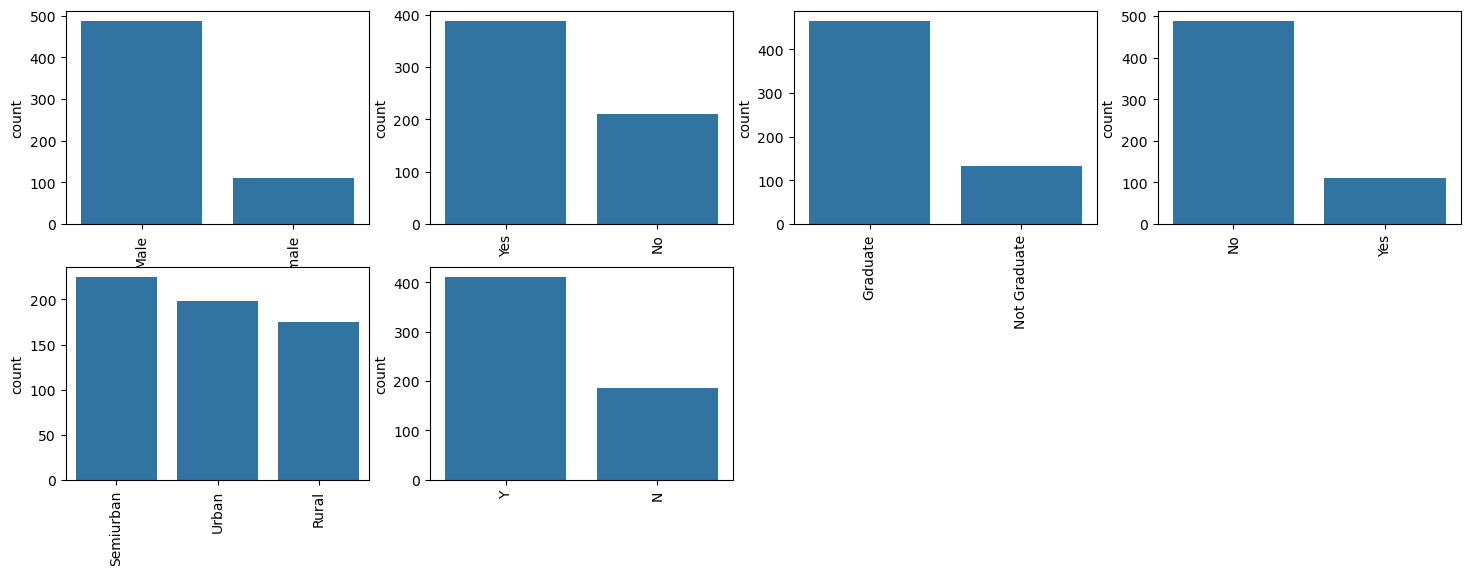

In [6]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
plt.figure(figsize=(18,36))
index = 1

for col in object_cols:
  y = data[col].value_counts()
  plt.subplot(11,4,index)
  plt.xticks(rotation=90)
  sns.barplot(x=list(y.index), y=y)
  index +=1

In [7]:
print("Loan_ID" in data.columns)

False


In [8]:
data.head(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# Import label encoder
from sklearn import preprocessing
  
# label_encoder object knows how 
# to understand word labels.
label_encoder = preprocessing.LabelEncoder()
obj = (data.dtypes == 'object')
for col in list(obj[obj].index):
  data[col] = label_encoder.fit_transform(data[col])

In [10]:
# To find the number of columns with 
# datatype==object
obj = (data.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 0


Text(0.5, 1.0, 'Correlation Heatmap (Coolwarm)')

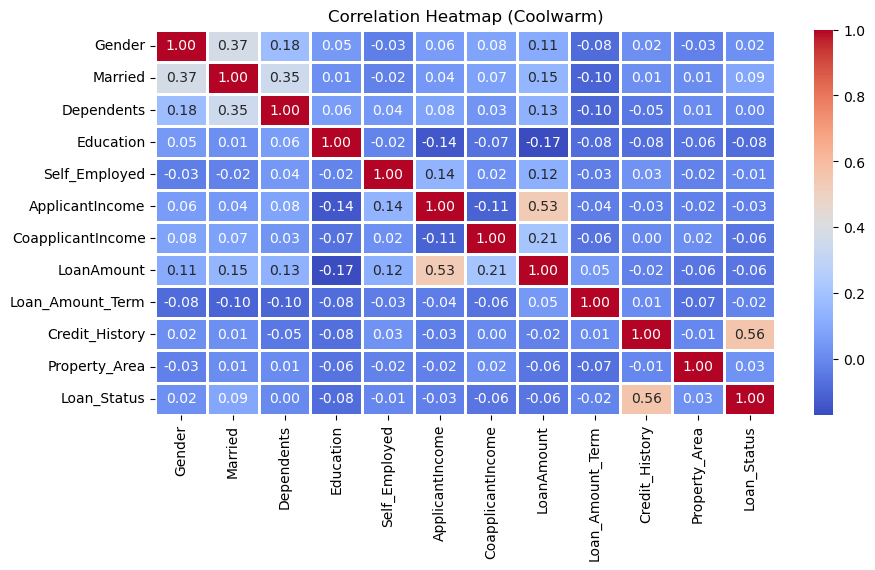

In [11]:
plt.figure(figsize=(10, 5))
# Uses 'coolwarm' for a classic red-blue divergence
sns.heatmap(data.corr(), cmap='coolwarm', fmt='.2f', linewidths=2, annot=True)
plt.title('Correlation Heatmap (Coolwarm)')

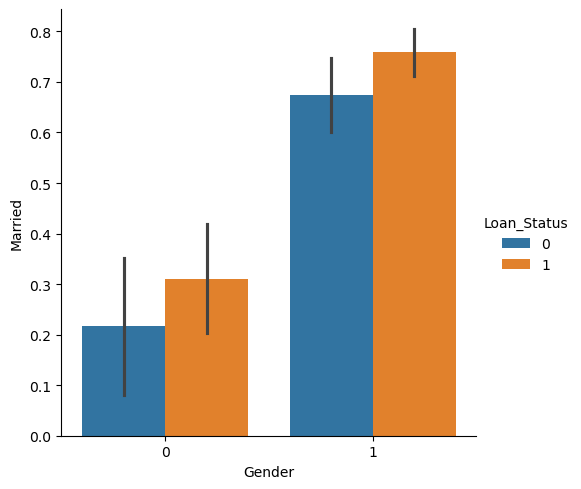

In [12]:
sns.catplot(x="Gender", y="Married",
            hue="Loan_Status", 
            kind="bar", 
            data=data)

In [13]:
for col in data.columns:
  data[col] = data[col].fillna(data[col].mean()) 
  
data.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

X = data.drop(['Loan_Status'], axis=1)
Y = data['Loan_Status']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=1)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(358, 11) (240, 11) (358,) (240,)


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

knn = KNeighborsClassifier(n_neighbors=3)
rfc = RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)
svc = SVC()
lc = LogisticRegression(max_iter=1000)

# Evaluate performance on test data
for clf in (rfc, knn, svc, lc):
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)
    print("Accuracy score of", clf.__class__.__name__, "=", 100 * metrics.accuracy_score(Y_test, Y_pred))

Accuracy score of RandomForestClassifier = 82.5
Accuracy score of KNeighborsClassifier = 63.74999999999999
Accuracy score of SVC = 69.16666666666667
Accuracy score of LogisticRegression = 82.5


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize and fit the scaler on feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Re-train Logistic Regression on scaled data
lc = LogisticRegression(max_iter=1000)
lc.fit(X_train_scaled, Y_train)

# 3. Evaluate accuracy on scaled test data
Y_pred = lc.predict(X_test_scaled)
print("Scaled Logistic Regression Accuracy:", 100 * metrics.accuracy_score(Y_test, Y_pred))

Scaled Logistic Regression Accuracy: 82.08333333333333


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions from Random Forest
rfc.fit(X_train, Y_train)
Y_pred_rfc = rfc.predict(X_test)

print("--- Random Forest Classification Report ---")
print(classification_report(Y_test, Y_pred_rfc))

print("--- Confusion Matrix ---")
print(confusion_matrix(Y_test, Y_pred_rfc))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.62      0.68        73
           1       0.85      0.92      0.88       167

    accuracy                           0.82       240
   macro avg       0.80      0.77      0.78       240
weighted avg       0.82      0.82      0.82       240

--- Confusion Matrix ---
[[ 45  28]
 [ 14 153]]


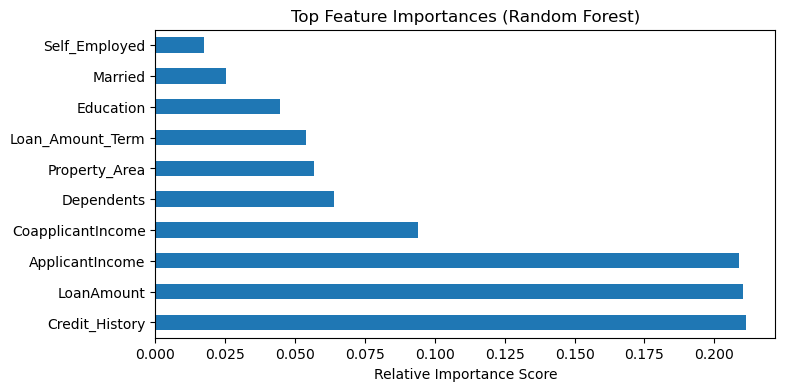

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importance = pd.Series(rfc.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh', figsize=(8, 4))

plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Relative Importance Score')
plt.show()

In [19]:
import joblib

# Save model and scaler for deployment
joblib.dump(rfc, 'loan_approval_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Example prediction function
def predict_loan_status(applicant_data):
    # Process and scale input data
    scaled_input = scaler.transform(applicant_data)
    prediction = rfc.predict(scaled_input)
    return "Approved" if prediction[0] == 1 else "Rejected"